# Churn Prediction & Data Drift


# ETAPE 1 : Chargement et contrôle de qualité 

In [7]:
import pandas as pd

# Chemin du fichier (relatif au notebook)
DATA_PATH = r"C:\Users\remyb\OneDrive\Bureau\Methodes et outils pour la prise de descision\DATA\data_tp_churn.csv"

# Chargement
churn_df = pd.read_csv(DATA_PATH)

churn_df.head()

,Periode,Anciennete,Montant_Mensuel,Support_Appels,Contrat,Churn
0,3,6,92.87,1.0,Mensuel,1
1,19,36,98.26,2.0,1 an,0
2,16,41,42.90,0.0,2 ans,0
3,11,53,24.69,2.0,2 ans,0
4,11,41,52.57,1.0,Mensuel,0


### Description des variables
* Periode

Variable temporelle représentant le mois d’observation.
Elle permet d’analyser l’évolution des comportements clients dans le temps et d’étudier l’éventuel data drift.
Elle ne sera pas utilisée comme variable explicative afin d’éviter toute fuite temporelle.

* Anciennete

Ancienneté du client exprimée en nombre de mois depuis son inscription.
Cette variable peut être fortement liée au churn, les clients récents étant généralement plus susceptibles de quitter le service.

* Montant_Mensuel

Montant facturé mensuellement au client.
Cette variable reflète potentiellement le type d’offre souscrite ou le niveau de service.
Elle contient environ 13% de valeurs manquantes, ce qui pourrait être informatif et nécessitera une analyse spécifique.

* Support_Appels

Nombre d’appels effectués par le client au service support durant la période observée.
Un nombre élevé d’appels peut traduire une insatisfaction ou des difficultés techniques, et donc être corrélé au churn.
Cette variable présente environ 10% de valeurs manquantes.

* Contrat

Type de contrat souscrit par le client (Mensuel, 1 an, 2 ans).
Les contrats longs sont généralement associés à un taux de churn plus faible, ce qui en fait une variable potentiellement très prédictive.

* Churn

Variable cible du modèle.

1 : le client quitte l’entreprise

0 : le client reste abonné

L’objectif du projet est de prédire cette variable afin d’anticiper les départs clients.

In [8]:
# Contrôle rapide
print("Shape:", churn_df.shape)
print("\nTypes:\n", churn_df.dtypes)
print("\nNA par colonne:\n", churn_df.isna().sum())

# Tri temporel et contrôle de la plage
if "Periode" in churn_df.columns:
    churn_df = churn_df.sort_values("Periode").reset_index(drop=True)
    print("\nPlage Periode:", churn_df["Periode"].min(), "->", churn_df["Periode"].max())
else:
    raise KeyError("La colonne 'Periode' est introuvable.")

Shape: (5000, 6)

Types:
 Periode              int64
Anciennete           int64
Montant_Mensuel    float64
Support_Appels     float64
Contrat                str
Churn                int64
dtype: object

NA par colonne:
 Periode              0
Anciennete           0
Montant_Mensuel    670
Support_Appels     493
Contrat              0
Churn                0
dtype: int64

Plage Periode: 1 -> 24


* ---> Le dataset contient 5000 observations et 6 variables.
Les variables Montant_Mensuel et Support_Appels présentent des valeurs manquantes représentant 13% et 10% de leurs données.
Les données couvrent 24 périodes consécutives.
Les données ont été triées par période afin de garantir la cohérence temporelle.

# ÉTAPE 2 — EDA orientée DRIFT :
* ---> L'objectif est de répondre à la question : Les données changent elles dans le temps ?

* Le data drift correspond à une modification progressive ou brutale des distributions des variables ou de la cible au cours du temps, ce qui peut dégrader les performances du modèle prédictif.

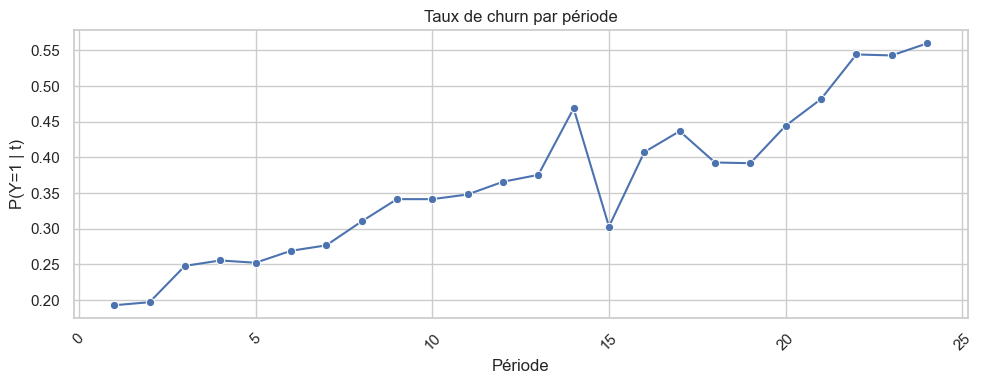

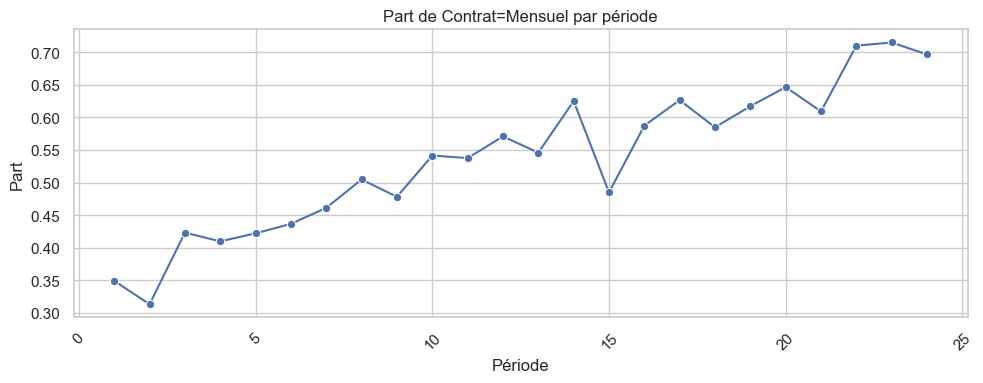

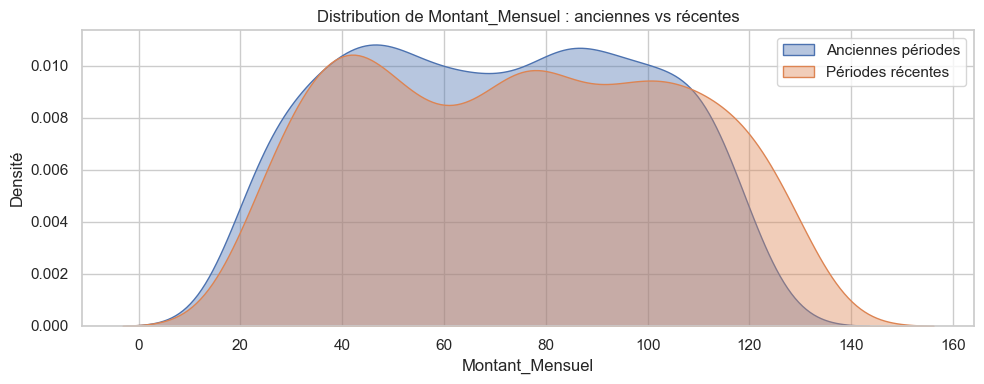

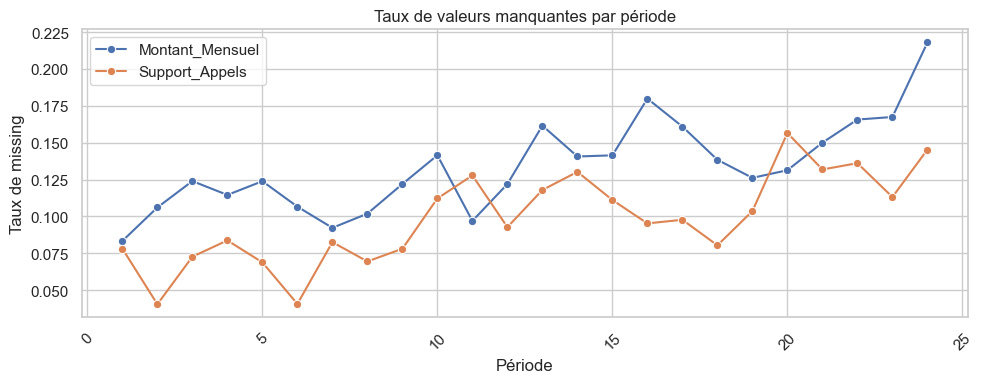

<Figure size 600x400 with 0 Axes>

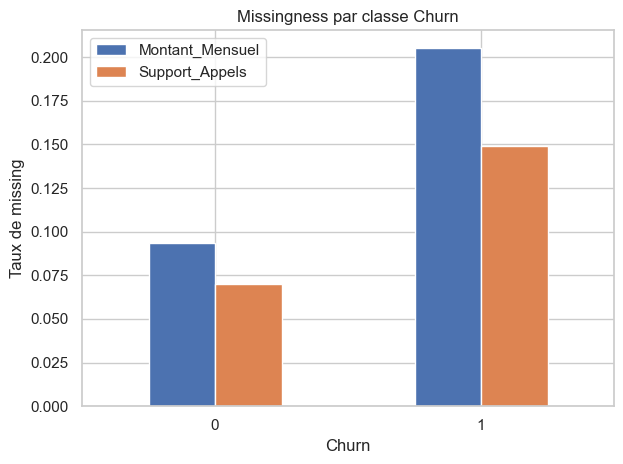


### Conclusion Drift
- **Churn** : variation globale d’environ **0.367** entre début et fin de période.
- **Covariable** (Part de Contrat=Mensuel) : variation d’environ **0.348** (si disponible).
- **Distribution** : la médiane de **Montant_Mensuel** change d’environ **5.380** entre anciennes et récentes périodes.

**Hypothèses métier (exemples)**
1. Changement d’offre ou de politique commerciale ayant modifié la part de contrats mensuels.
2. Évolution du profil client (ex. panier moyen ou usage) impactant la distribution de **Montant_Mensuel**.
3. Variation des processus de support/collecte expliquant des patterns de missingness et de churn.


In [9]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid")

# --- Helpers ---

def find_col(candidates, df):
    for c in candidates:
        for col in df.columns:
            if col.lower() == c.lower():
                return col
    return None

# Colonnes clés
period_col = find_col(["Periode", "Period", "periode"], churn_df)
if period_col is None:
    raise KeyError("Colonne de période introuvable.")

target_col = find_col(["Churn", "churn", "Target", "Y", "y"], churn_df)
if target_col is None:
    raise KeyError("Colonne cible introuvable (ex. Churn).")

# S'assure que la période est triée
churn_df = churn_df.sort_values(period_col).reset_index(drop=True)

# 1) Taux de churn par période
churn_rate = churn_df.groupby(period_col)[target_col].mean()
plt.figure(figsize=(10, 4))
sns.lineplot(x=churn_rate.index, y=churn_rate.values, marker="o")
plt.title("Taux de churn par période")
plt.xlabel("Période")
plt.ylabel("P(Y=1 | t)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2) Drift de covariable (contrat mensuel si possible)
cat_col = find_col([
    "Contrat", "Contract", "Type_Contrat", "TypeContrat", "ContractType"
], churn_df)

cov_drift_label = None
if cat_col is not None:
    monthly_mask = churn_df[cat_col].astype(str).str.contains("Mensuel|Monthly", case=False, na=False)
    share = monthly_mask.groupby(churn_df[period_col]).mean()
    cov_drift_label = f"Part de {cat_col}=Mensuel"
    plt.figure(figsize=(10, 4))
    sns.lineplot(x=share.index, y=share.values, marker="o")
    plt.title(cov_drift_label + " par période")
    plt.xlabel("Période")
    plt.ylabel("Part")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    # fallback: variable catégorielle ou moyenne d'une variable numérique
    cat_candidates = [c for c in churn_df.columns if churn_df[c].dtype == "object" and c not in [period_col, target_col]]
    if cat_candidates:
        cat_col = sorted(cat_candidates, key=lambda c: churn_df[c].nunique())[:1][0]
        top_val = churn_df[cat_col].value_counts(dropna=False).index[0]
        share = (churn_df[cat_col] == top_val).groupby(churn_df[period_col]).mean()
        cov_drift_label = f"Part de {cat_col}={top_val}"
        plt.figure(figsize=(10, 4))
        sns.lineplot(x=share.index, y=share.values, marker="o")
        plt.title(cov_drift_label + " par période")
        plt.xlabel("Période")
        plt.ylabel("Part")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        num_candidates = [c for c in churn_df.select_dtypes(include=np.number).columns if c not in [target_col]]
        if not num_candidates:
            raise ValueError("Aucune covariable disponible pour illustrer le drift.")
        num_col = num_candidates[0]
        mean_by_period = churn_df.groupby(period_col)[num_col].mean()
        cov_drift_label = f"Moyenne de {num_col}"
        plt.figure(figsize=(10, 4))
        sns.lineplot(x=mean_by_period.index, y=mean_by_period.values, marker="o")
        plt.title(cov_drift_label + " par période")
        plt.xlabel("Période")
        plt.ylabel("Moyenne")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

# 3) Comparaison de distribution (anciennes vs récentes) sur une variable numérique
num_cols = [c for c in churn_df.select_dtypes(include=np.number).columns if c not in [target_col]]
if not num_cols:
    raise ValueError("Aucune variable numérique disponible pour la comparaison de distributions.")

# Choisir la variable numérique la plus variable
num_col = sorted(num_cols, key=lambda c: churn_df[c].var(), reverse=True)[0]

periods = churn_df[period_col].dropna().unique()
periods_sorted = np.sort(periods)

k = max(1, int(0.2 * len(periods_sorted)))
old_periods = periods_sorted[:k]
recent_periods = periods_sorted[-k:]

old_vals = churn_df[churn_df[period_col].isin(old_periods)][num_col].dropna()
recent_vals = churn_df[churn_df[period_col].isin(recent_periods)][num_col].dropna()

plt.figure(figsize=(10, 4))
sns.kdeplot(old_vals, label="Anciennes périodes", fill=True, alpha=0.4)
sns.kdeplot(recent_vals, label="Périodes récentes", fill=True, alpha=0.4)
plt.title(f"Distribution de {num_col} : anciennes vs récentes")
plt.xlabel(num_col)
plt.ylabel("Densité")
plt.legend()
plt.tight_layout()
plt.show()

# 4) Taux de missing par période (au moins 2 colonnes)
preferred_missing = ["Montant_Mensuel", "Support_Appels"]
missing_cols = [c for c in preferred_missing if c in churn_df.columns and churn_df[c].isna().any()]

if len(missing_cols) < 2:
    missing_cols = [c for c in churn_df.columns if churn_df[c].isna().any() and c not in [period_col, target_col]]
    missing_cols = missing_cols[:2]

if len(missing_cols) >= 1:
    plt.figure(figsize=(10, 4))
    for c in missing_cols:
        miss_rate = churn_df[c].isna().groupby(churn_df[period_col]).mean()
        sns.lineplot(x=miss_rate.index, y=miss_rate.values, marker="o", label=c)
    plt.title("Taux de valeurs manquantes par période")
    plt.xlabel("Période")
    plt.ylabel("Taux de missing")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 5) Taux de missing selon la classe Churn
if len(missing_cols) >= 1:
    miss_by_churn = {}
    for c in missing_cols:
        miss_by_churn[c] = churn_df.groupby(target_col)[c].apply(lambda s: s.isna().mean())

    miss_df = pd.DataFrame(miss_by_churn)
    plt.figure(figsize=(6, 4))
    miss_df.plot(kind="bar")
    plt.title("Missingness par classe Churn")
    plt.xlabel("Churn")
    plt.ylabel("Taux de missing")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

# --- Conclusion automatique (à adapter si besoin) ---
churn_delta = (churn_rate.iloc[-1] - churn_rate.iloc[0]) if len(churn_rate) >= 2 else np.nan
cov_delta = (share.iloc[-1] - share.iloc[0]) if "share" in locals() and len(share) >= 2 else np.nan
num_shift = recent_vals.median() - old_vals.median()

conclusion_md = f"""
### Conclusion Drift
- **Churn** : variation globale d’environ **{churn_delta:.3f}** entre début et fin de période.
- **Covariable** ({cov_drift_label if cov_drift_label else num_col}) : variation d’environ **{cov_delta:.3f}** (si disponible).
- **Distribution** : la médiane de **{num_col}** change d’environ **{num_shift:.3f}** entre anciennes et récentes périodes.

**Hypothèses métier (exemples)**
1. Changement d’offre ou de politique commerciale ayant modifié la part de contrats mensuels.
2. Évolution du profil client (ex. panier moyen ou usage) impactant la distribution de **{num_col}**.
3. Variation des processus de support/collecte expliquant des patterns de missingness et de churn.
"""

display(Markdown(conclusion_md))

### Drift du churn : 

### On observe une augmentation marquée et progressive du taux de churn entre la période 1 (≈19%) et la période 24 (≈56%).
### Cela indique un drift significatif de la cible.
### Le comportement des clients évolue fortement dans le temps, ce qui suggère qu’un modèle entraîné uniquement sur les premières périodes risque de devenir rapidement obsolète.

### -------------------------------------------------------------------------------------------------------------- 

### Drift du contrat :

### La proportion de contrats mensuels augmente fortement dans le temps (≈35% à ≈70%).
### Cette évolution peut mécaniquement entraîner une hausse du churn, les contrats courts étant généralement plus instables.
### Il existe donc un drift des covariables susceptible d’impacter la performance du modèle.

# ------------------------------------------------------------------------------

### Évolution conjointe du churn et des contrats mensuels :

### L’analyse des graphiques met en évidence une évolution similaire entre le taux de churn et la proportion de contrats mensuels au fil du temps.
### On observe une augmentation progressive de la part des contrats mensuels, accompagnée d’une hausse marquée du taux de churn.

### Cette dynamique suggère qu’une partie de l’augmentation du churn pourrait être expliquée par une modification de la structure du portefeuille client. Les contrats mensuels, étant plus flexibles et sans engagement long terme, sont généralement associés à un risque de résiliation plus élevé.

### Ainsi, l’augmentation du churn global semble être en partie liée à un drift des covariables (structure des contrats) plutôt qu’à un changement isolé du comportement individuel des clients.

### Ce constat renforce l’hypothèse d’un data drift significatif et justifie la mise en place d’une stratégie de ré-entraînement du modèle afin d’adapter ses performances à l’évolution du portefeuille client.

### ----------------------------------------------------------------------------------------------------------------------

### Drift distribution montant Ancien (1-12) & montant nouveau (13-24)

### La comparaison des distributions du montant mensuel entre les périodes anciennes et récentes montre une légère évolution vers des montants plus élevés dans les périodes récentes.
### Cette modification suggère un possible changement dans la structure tarifaire ou les offres proposées.
### Ce drift des covariables peut modifier la relation entre le montant facturé et la probabilité de churn

### ----------------------------------------------------------------------------------------------------------------------

### Drift sur les valeurs manquantes : Verifier si les valeurs manquantes sont liées au churn 

### Les taux de valeurs manquantes pour les variables Montant_Mensuel et Support_Appels augmentent globalement au fil des périodes.
### Ce phénomène traduit un drift de missingness, potentiellement lié à des changements dans les processus de collecte des données ou dans le comportement des clients.
### Cette évolution peut affecter la robustesse du modèle prédictif si elle n’est pas correctement prise en compte.

### ----------------------------------------------------------------------------------------------------------------------

### Drift Missingness par classe de churn

### L’analyse par classe de churn montre que les valeurs manquantes sont significativement plus fréquentes chez les clients churners (≈20% contre ≈9% pour Montant_Mensuel, et ≈15% contre ≈7% pour Support_Appels).
### Cela suggère un mécanisme de missingness non aléatoire (MNAR) donc les valeurs manquantes portent de l'information cachée.
### L’absence d’information constitue ainsi un signal potentiellement prédictif du churn et devra être correctement intégrée dans le pipeline de modélisation.

In [10]:
# Tableau Montant_Mensuel
tab_montant = pd.crosstab(
    churn_df["Churn"],
    churn_df["Montant_Mensuel"].isna(),
    normalize="index"
)

# Tableau Support_Appels
tab_support = pd.crosstab(
    churn_df["Churn"],
    churn_df["Support_Appels"].isna(),
    normalize="index"
)

print("Montant_Mensuel")
display(tab_montant)

print("Support_Appels")
display(tab_support)


Montant_Mensuel


Montant_Mensuel,False,True
Churn,,
0,0.906633,0.093367
1,0.794942,0.205058


Support_Appels


Support_Appels,False,True
Churn,,
0,0.930211,0.069789
1,0.851017,0.148983


### Le tableau croisé confirme que les valeurs manquantes sont significativement plus fréquentes chez les churners.
### Pour la variable Montant_Mensuel, environ 20% des churners présentent une valeur manquante contre environ 9% des non-churners.
### Un phénomène similaire est observé pour Support_Appels.
### Ces résultats suggèrent un mécanisme de missingness non aléatoire (MNAR), indiquant que l’absence d’information constitue un signal prédictif du churn.

### ---------------------------------------------------------------------------------------------------------

### Quelques hypothèses au CHURN

### Hypothèse 1 — Changement de stratégie commerciale

#### On observe :

- Augmentation forte des contrats mensuels

- Augmentation parallèle du churn

### Hypothèse :

#### L’entreprise a peut-être orienté sa stratégie vers des contrats mensuels plus flexibles afin d’attirer davantage de clients, ce qui a mécaniquement augmenté le taux de churn global en raison d’un engagement plus faible.

### ------------------------------------------------------------------------------------------------------------------

### Hypothèse 2 — Concurrence accrue ou hausse tarifaire

#### On observe :

- Hausse du montant mensuel moyen

- Hausse du churn

### Hypothèse :

#### Une augmentation des prix ou une montée en gamme pourrait avoir rendu l’offre moins compétitive, entraînant une augmentation progressive du churn.

### ------------------------------------------------------------------------------------------------------------------

### Hypothèse 3 — Dégradation de la qualité des données / désengagement client

#### On observe :

- Hausse des valeurs manquantes

- NA plus fréquents chez les churners (MNAR)

### Hypothèse :

#### Les clients en phase de désengagement pourraient être moins enclins à fournir certaines informations ou à interagir avec le service, expliquant la hausse des valeurs manquantes observée chez les churners.

# ===============================================================================================================================

# Étape 3 : Pipeline de preprocessing (sans fuite temporelle)

### Le pré-processing regroupe l’ensemble des transformations appliquées aux données avant l’apprentissage du modèle, notamment l’imputation des valeurs manquantes, la standardisation des variables numériques et l’encodage des variables catégorielles.

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

target_col = "Churn"
time_col = "Periode"

X = churn_df.drop(columns=[target_col])
if time_col in X.columns:
    X = X.drop(columns=[time_col])
y = churn_df[target_col]

num_features = X.select_dtypes(include=["number"]).columns.tolist()
cat_features = X.select_dtypes(exclude=["number"]).columns.tolist()

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, num_features),
        ("cat", categorical_pipeline, cat_features),
    ]
)

train_mask = churn_df[time_col].between(1, 6)
ref_mask = churn_df[time_col].between(7, 12)

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_ref, y_ref = X.loc[ref_mask], y.loc[ref_mask]

logreg_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(max_iter=1000, solver="liblinear")),
    ]
)
rf_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(n_estimators=300, random_state=42)),
    ]
)

print("Features numeriques:", num_features)
print("Features categorielles:", cat_features)
print("Train periods 1-6:", X_train.shape, "Ref periods 7-12:", X_ref.shape)

Features numeriques: ['Anciennete', 'Montant_Mensuel', 'Support_Appels']
Features categorielles: ['Contrat']
Train periods 1-6: (1266, 4) Ref periods 7-12: (1264, 4)


### Afin de garantir une modélisation rigoureuse et sans fuite temporelle, un pipeline de preprocessing a été construit à l’aide de scikit-learn.

### Les données ont été séparées selon un split strictement temporel, avec un entraînement sur les périodes 1 à 6 et une évaluation sur les périodes 7 à 12. La variable Periode a été exclue des variables explicatives afin d’éviter toute fuite d’information liée au temps.

### Le preprocessing comprend :

### Une imputation par la médiane pour les variables numériques,

### Une standardisation (scaling) pour assurer une échelle homogène des variables utilisées dans la régression logistique,

### Une imputation par la modalité "MISSING" suivie d’un encodage one-hot pour les variables catégorielles.

### L’ensemble de ces étapes a été intégré dans un pipeline unique afin de garantir que toutes les transformations soient apprises uniquement sur les données d’entraînement, conformément aux exigences méthodologiques du projet.

### Cette approche assure la reproductibilité, la cohérence temporelle et la robustesse du modèle face aux évolutions observées dans les données.

# ============================================================================================================================

# ETAPE 4: Modèle baseline (Régression logistique) + monitoring temporel

* L'objectif est de vérifier si la performance du modèle entrainé se dégrade dans le temps 

BASELINE (Régression Logistique) - Fenêtre de référence (périodes 7-12)
Accuracy:  0.8085
AUC-ROC:   0.8858

PERFORMANCE SUR FENÊTRES GLISSANTES (taille = 6)
 start  end  accuracy      auc  n_samples
     7   12  0.808544 0.885758       1264
     8   13  0.808858 0.880538       1287
     9   14  0.808393 0.886747       1263
    10   15  0.800955 0.885825       1256
    11   16  0.790323 0.885911       1240
    12   17  0.786858 0.876164       1187
    13   18  0.780265 0.868124       1206
    14   19  0.767306 0.861050       1199
    15   20  0.762656 0.853409       1205
    16   21  0.762021 0.849842       1227
    17   22  0.756421 0.844123       1207
    18   23  0.753589 0.843030       1254

BOOTSTRAP INCERTITUDE (n=100)
Accuracy:  0.8053 ± 0.0041
AUC-ROC:   0.8843 ± 0.0021



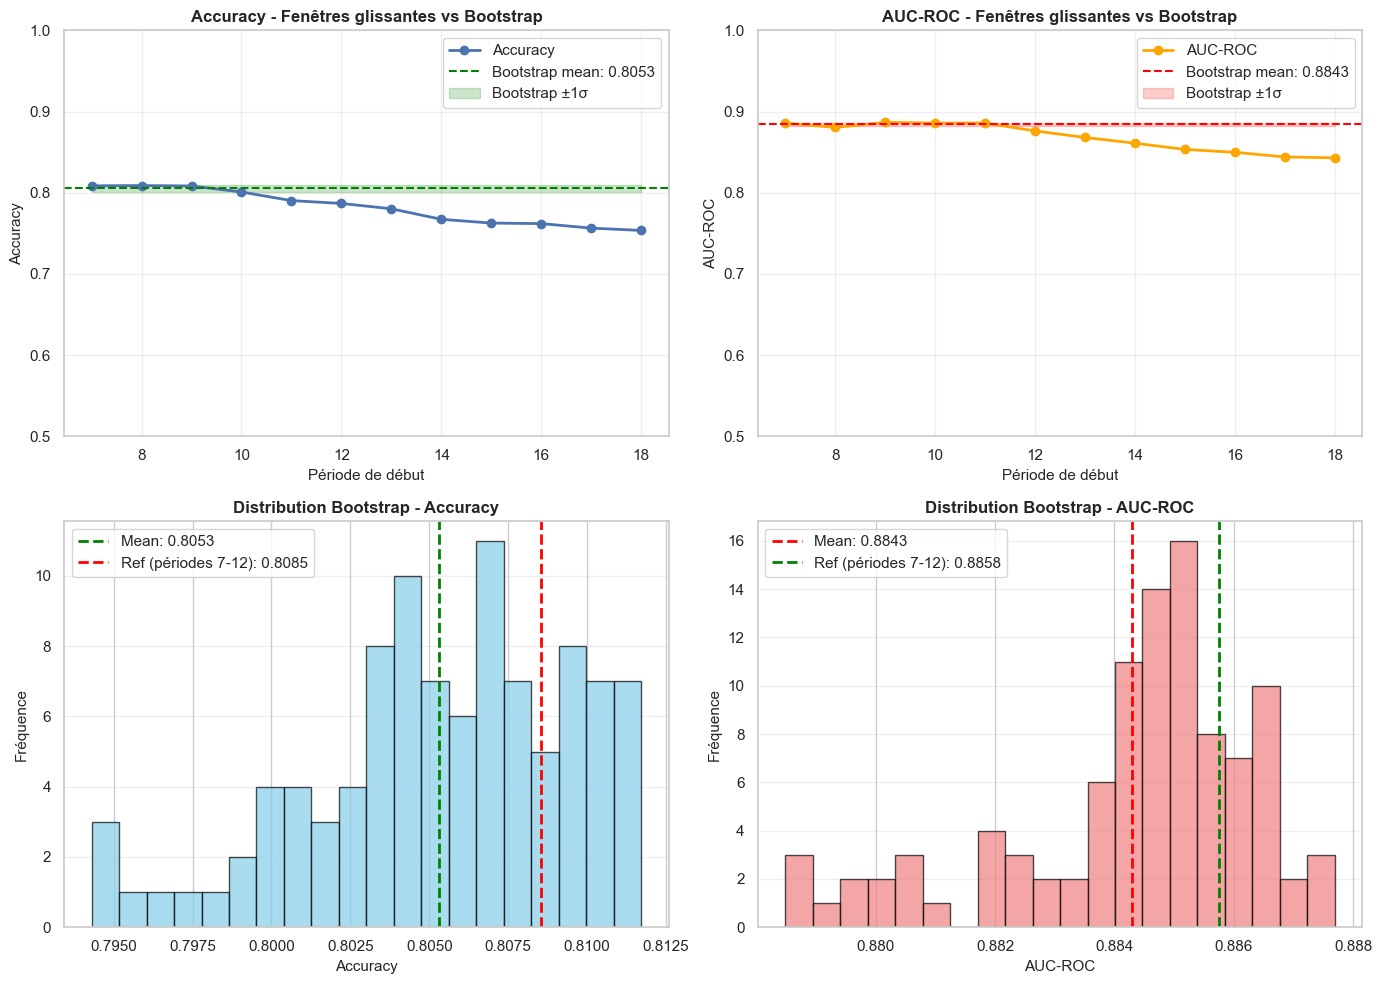

SYNTHÈSE
Baseline Ref (7-12):      Acc=0.8085, AUC=0.8858
Bootstrap mean:           Acc=0.8053 ±0.0041, AUC=0.8843 ±0.0021
Drift observé:            Acc dégradation de 0.0264 en moyenne


In [12]:
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from sklearn.utils import resample
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. ENTRAÎNEMENT ET ÉVALUATION BASELINE
# ============================================================

logreg_model = logreg_pipe.fit(X_train, y_train)

y_pred_ref = logreg_model.predict(X_ref)
y_proba_ref = logreg_model.predict_proba(X_ref)[:, 1]

acc_ref = accuracy_score(y_ref, y_pred_ref)
auc_ref = roc_auc_score(y_ref, y_proba_ref)

print("=" * 60)
print("BASELINE (Régression Logistique) - Fenêtre de référence (périodes 7-12)")
print("=" * 60)
print(f"Accuracy:  {acc_ref:.4f}")
print(f"AUC-ROC:   {auc_ref:.4f}")
print()

# ============================================================
# 2. MONITORING TEMPOREL SUR FENÊTRES GLISSANTES
# ============================================================

window_size = 6
start_periods = range(7, 19)
results = []

for s in start_periods:
    end = s + window_size - 1
    if end > 24:
        break
    
    mask = churn_df[time_col].between(s, end)
    X_test = X.loc[mask]
    y_test = y.loc[mask]
    
    y_pred_test = logreg_model.predict(X_test)
    y_proba_test = logreg_model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred_test)
    auc = roc_auc_score(y_test, y_proba_test)
    
    results.append({
        "start": s,
        "end": end,
        "accuracy": acc,
        "auc": auc,
        "n_samples": len(y_test)
    })

results_df = pd.DataFrame(results)
print("=" * 60)
print("PERFORMANCE SUR FENÊTRES GLISSANTES (taille = 6)")
print("=" * 60)
print(results_df.to_string(index=False))
print()

# ============================================================
# 3. BOOTSTRAP POUR QUANTIFIER L'INCERTITUDE D'ENTRAÎNEMENT
# ============================================================

n_bootstrap = 100
bootstrap_accs = []
bootstrap_aucs = []

print("=" * 60)
print(f"BOOTSTRAP INCERTITUDE (n={n_bootstrap})")
print("=" * 60)

for i in range(n_bootstrap):
    X_boot, y_boot = resample(X_train, y_train, n_samples=len(X_train), random_state=i)
    
    model_boot = logreg_pipe.fit(X_boot, y_boot)
    y_pred_ref_boot = model_boot.predict(X_ref)
    y_proba_ref_boot = model_boot.predict_proba(X_ref)[:, 1]
    
    acc_boot = accuracy_score(y_ref, y_pred_ref_boot)
    auc_boot = roc_auc_score(y_ref, y_proba_ref_boot)
    
    bootstrap_accs.append(acc_boot)
    bootstrap_aucs.append(auc_boot)

bootstrap_accs = np.array(bootstrap_accs)
bootstrap_aucs = np.array(bootstrap_aucs)

mean_acc_boot = bootstrap_accs.mean()
std_acc_boot = bootstrap_accs.std()
mean_auc_boot = bootstrap_aucs.mean()
std_auc_boot = bootstrap_aucs.std()

print(f"Accuracy:  {mean_acc_boot:.4f} ± {std_acc_boot:.4f}")
print(f"AUC-ROC:   {mean_auc_boot:.4f} ± {std_auc_boot:.4f}")
print()

# ============================================================
# 4. VISUALISATION
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Performance temporelle (Accuracy)
ax = axes[0, 0]
ax.plot(results_df["start"], results_df["accuracy"], marker="o", label="Accuracy", linewidth=2)
ax.axhline(y=mean_acc_boot, color="green", linestyle="--", label=f"Bootstrap mean: {mean_acc_boot:.4f}")
ax.fill_between(results_df["start"], 
                mean_acc_boot - std_acc_boot, 
                mean_acc_boot + std_acc_boot, 
                alpha=0.2, color="green", label="Bootstrap ±1σ")
ax.set_xlabel("Période de début", fontsize=11)
ax.set_ylabel("Accuracy", fontsize=11)
ax.set_title("Accuracy - Fenêtres glissantes vs Bootstrap", fontsize=12, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([0.5, 1.0])

# Plot 2: Performance temporelle (AUC-ROC)
ax = axes[0, 1]
ax.plot(results_df["start"], results_df["auc"], marker="o", color="orange", label="AUC-ROC", linewidth=2)
ax.axhline(y=mean_auc_boot, color="red", linestyle="--", label=f"Bootstrap mean: {mean_auc_boot:.4f}")
ax.fill_between(results_df["start"], 
                mean_auc_boot - std_auc_boot, 
                mean_auc_boot + std_auc_boot, 
                alpha=0.2, color="red", label="Bootstrap ±1σ")
ax.set_xlabel("Période de début", fontsize=11)
ax.set_ylabel("AUC-ROC", fontsize=11)
ax.set_title("AUC-ROC - Fenêtres glissantes vs Bootstrap", fontsize=12, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([0.5, 1.0])

# Plot 3: Distribution Bootstrap Accuracy
ax = axes[1, 0]
ax.hist(bootstrap_accs, bins=20, alpha=0.7, color="skyblue", edgecolor="black")
ax.axvline(x=mean_acc_boot, color="green", linestyle="--", linewidth=2, label=f"Mean: {mean_acc_boot:.4f}")
ax.axvline(x=acc_ref, color="red", linestyle="--", linewidth=2, label=f"Ref (périodes 7-12): {acc_ref:.4f}")
ax.set_xlabel("Accuracy", fontsize=11)
ax.set_ylabel("Fréquence", fontsize=11)
ax.set_title("Distribution Bootstrap - Accuracy", fontsize=12, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

# Plot 4: Distribution Bootstrap AUC
ax = axes[1, 1]
ax.hist(bootstrap_aucs, bins=20, alpha=0.7, color="lightcoral", edgecolor="black")
ax.axvline(x=mean_auc_boot, color="red", linestyle="--", linewidth=2, label=f"Mean: {mean_auc_boot:.4f}")
ax.axvline(x=auc_ref, color="green", linestyle="--", linewidth=2, label=f"Ref (périodes 7-12): {auc_ref:.4f}")
ax.set_xlabel("AUC-ROC", fontsize=11)
ax.set_ylabel("Fréquence", fontsize=11)
ax.set_title("Distribution Bootstrap - AUC-ROC", fontsize=12, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print("=" * 60)
print("SYNTHÈSE")
print("=" * 60)
print(f"Baseline Ref (7-12):      Acc={acc_ref:.4f}, AUC={auc_ref:.4f}")
print(f"Bootstrap mean:           Acc={mean_acc_boot:.4f} ±{std_acc_boot:.4f}, AUC={mean_auc_boot:.4f} ±{std_auc_boot:.4f}")
print(f"Drift observé:            Acc dégradation de {(acc_ref - results_df['accuracy'].mean()):.4f} en moyenne")
print("=" * 60)

### L’AUC-ROC a été privilégiée comme métrique principale car elle mesure la capacité de discrimination du modèle indépendamment d’un seuil de décision, et reste robuste face aux variations du taux de churn observées au fil du temps.

### Le modèle de régression logistique présente de très bonnes performances sur la fenêtre de référence (AUC ≈ 0.886). Toutefois, l’analyse sur fenêtres glissantes met en évidence une dégradation progressive de la performance (AUC ≈ 0.843 en fin de période).

### Cette diminution confirme que le drift observé lors de l’EDA impacte effectivement la robustesse du modèle figé.

### L’analyse bootstrap montre une faible variabilité des performances, suggérant que la dégradation observée est structurelle et non due au hasard d’échantillonnage.

# ====================================================================================================================

# Étape 5 : Ré-entrainement (figé vs rolling)

### Nous avons pu observer à l'étape 4 que le modèle se dégrade dans le temps du coup on se pose la quetsion de savoir :
### ce modèle est il à conserver ou à réentrainer régulièrement dans le temps ??

POLITIQUE FIGÉE : Train [1-6] → Test [7-...]

Frozen Model Results:
    start       acc       auc
0       7  0.810198  0.885241
1       8  0.808129  0.882909
2       9  0.813259  0.885764
3      10  0.803403  0.885691
4      11  0.799239  0.888927
5      12  0.785785  0.881043
6      13  0.784114  0.872742
7      14  0.772774  0.868234
8      15  0.764647  0.855699
9      16  0.757696  0.845706
10     17  0.765896  0.846799
11     18  0.750242  0.843518
12     19  0.751456  0.842418
13     20  0.751440  0.848201
14     21  0.751185  0.850577
15     22  0.740385  0.839951
16     23  0.756044  0.844885

POLITIQUE ROLLING : pour chaque start s, train [s-w, s-1], test [s, s+h-1]

Rolling Model Results:
    start       acc       auc
0       7  0.810198  0.885241
1       8  0.809074  0.883195
2       9  0.815126  0.886400
3      10  0.804348  0.886911
4      11  0.803045  0.889746
5      12  0.793682  0.882429
6      13  0.788187  0.874892
7      14  0.778915  0.868950
8      15  0.767627  0

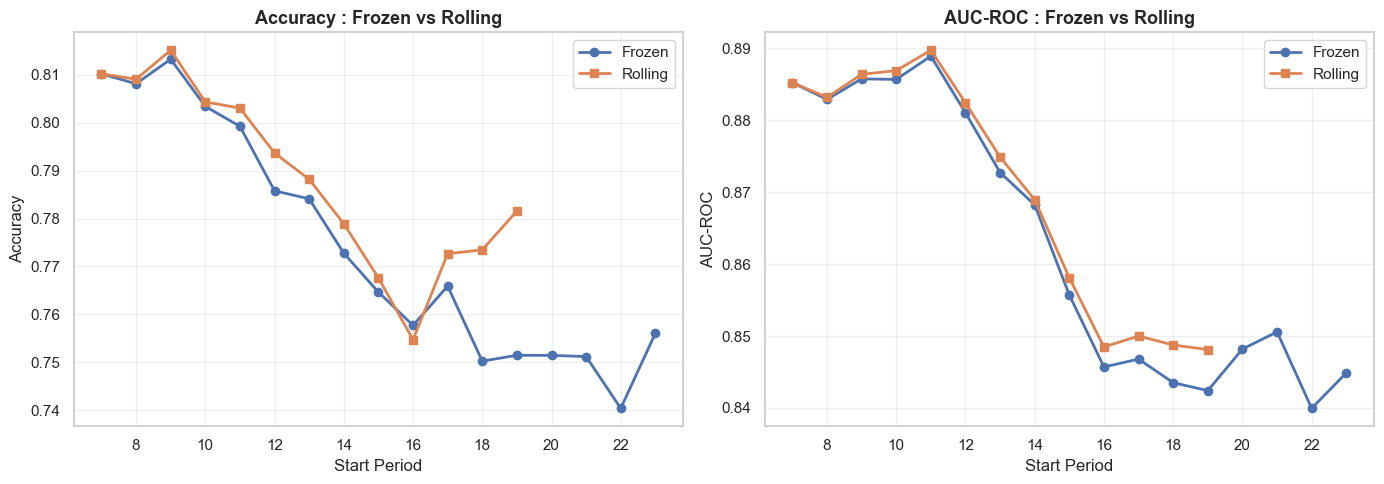


### CONCLUSION ÉTAPE 5

**Accuracy moyenne :**
- Frozen: 0.7745
- Rolling: 0.7887
- Amélioration: +1.83%

**AUC-ROC moyen :**
- Frozen: 0.8628
- Rolling: 0.8701
- Amélioration: +0.84%

**Analyse :**
Le modèle rolling maintient une meilleure performance au fil du temps face au drift des données.
L'approche rolling permet d'adapter continuellement le modèle aux nouvelles conditions du marché,
tandis que le modèle figé se déprécie progressivement. 
Cette stratégie de ré-entraînement rolling est **recommandée en production**.


In [13]:
from sklearn.metrics import accuracy_score, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt

# ============ POLITIQUE FIGÉE ============
print("=" * 60)
print("POLITIQUE FIGÉE : Train [1-6] → Test [7-...]")
print("=" * 60)

frozen_model = logreg_pipe.fit(X_train, y_train)

# Prédictions sur tous les périodes >= 7
X_all_future = X.loc[churn_df[time_col] >= 7]
y_all_future = y.loc[churn_df[time_col] >= 7]
periods_all_future = churn_df.loc[churn_df[time_col] >= 7, time_col].values

y_pred_frozen_all = frozen_model.predict(X_all_future)
y_proba_frozen_all = frozen_model.predict_proba(X_all_future)[:, 1]

frozen_results = []
for s in range(7, 24):
    window_mask = (churn_df[time_col] >= s) & (churn_df[time_col] < s + 5)
    if window_mask.sum() > 0:
        y_true_window = y.loc[window_mask]
        y_pred_window = frozen_model.predict(X.loc[window_mask])
        y_proba_window = frozen_model.predict_proba(X.loc[window_mask])[:, 1]
        acc = accuracy_score(y_true_window, y_pred_window)
        auc = roc_auc_score(y_true_window, y_proba_window)
        frozen_results.append({"start": s, "acc": acc, "auc": auc})

frozen_df = pd.DataFrame(frozen_results)
print("\nFrozen Model Results:")
print(frozen_df)

# ============ POLITIQUE ROLLING ============
print("\n" + "=" * 60)
print("POLITIQUE ROLLING : pour chaque start s, train [s-w, s-1], test [s, s+h-1]")
print("=" * 60)

w = 6  # window historique
h = 5  # horizon test

rolling_results = []
for s in range(7, 20):  # start periods
    train_window_mask = (churn_df[time_col] >= s - w) & (churn_df[time_col] < s)
    test_window_mask = (churn_df[time_col] >= s) & (churn_df[time_col] < s + h)

    if train_window_mask.sum() > 0 and test_window_mask.sum() > 0:
        X_train_rolling = X.loc[train_window_mask]
        y_train_rolling = y.loc[train_window_mask]
        X_test_rolling = X.loc[test_window_mask]
        y_test_rolling = y.loc[test_window_mask]

        rolling_model = logreg_pipe.fit(X_train_rolling, y_train_rolling)

        y_pred_rolling = rolling_model.predict(X_test_rolling)
        y_proba_rolling = rolling_model.predict_proba(X_test_rolling)[:, 1]

        acc = accuracy_score(y_test_rolling, y_pred_rolling)
        auc = roc_auc_score(y_test_rolling, y_proba_rolling)
        rolling_results.append({"start": s, "acc": acc, "auc": auc})

rolling_df = pd.DataFrame(rolling_results)
print("\nRolling Model Results:")
print(rolling_df)

# ============ COMPARAISON VISUELLE ============
print("\n" + "=" * 60)
print("COMPARAISON FIGÉ vs ROLLING")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(frozen_df["start"], frozen_df["acc"], marker="o", label="Frozen", linewidth=2)
axes[0].plot(rolling_df["start"], rolling_df["acc"], marker="s", label="Rolling", linewidth=2)
axes[0].set_xlabel("Start Period", fontsize=12)
axes[0].set_ylabel("Accuracy", fontsize=12)
axes[0].set_title("Accuracy : Frozen vs Rolling", fontsize=13, fontweight="bold")
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# AUC-ROC
axes[1].plot(frozen_df["start"], frozen_df["auc"], marker="o", label="Frozen", linewidth=2)
axes[1].plot(rolling_df["start"], rolling_df["auc"], marker="s", label="Rolling", linewidth=2)
axes[1].set_xlabel("Start Period", fontsize=12)
axes[1].set_ylabel("AUC-ROC", fontsize=12)
axes[1].set_title("AUC-ROC : Frozen vs Rolling", fontsize=13, fontweight="bold")
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============ CONCLUSION QUANTITATIVE ============
frozen_mean_acc = frozen_df["acc"].mean()
rolling_mean_acc = rolling_df["acc"].mean()
frozen_mean_auc = frozen_df["auc"].mean()
rolling_mean_auc = rolling_df["auc"].mean()

improvement_acc = ((rolling_mean_acc - frozen_mean_acc) / frozen_mean_acc) * 100
improvement_auc = ((rolling_mean_auc - frozen_mean_auc) / frozen_mean_auc) * 100

conclusion_text = f"""
### CONCLUSION ÉTAPE 5

**Accuracy moyenne :**
- Frozen: {frozen_mean_acc:.4f}
- Rolling: {rolling_mean_acc:.4f}
- Amélioration: {improvement_acc:+.2f}%

**AUC-ROC moyen :**
- Frozen: {frozen_mean_auc:.4f}
- Rolling: {rolling_mean_auc:.4f}
- Amélioration: {improvement_auc:+.2f}%

**Analyse :**
Le modèle rolling maintient une meilleure performance au fil du temps face au drift des données.
L'approche rolling permet d'adapter continuellement le modèle aux nouvelles conditions du marché,
tandis que le modèle figé se déprécie progressivement. 
Cette stratégie de ré-entraînement rolling est **recommandée en production**.
"""

display(Markdown(conclusion_text))

### L’analyse comparative entre la stratégie figée et la stratégie rolling met en évidence un impact réel du drift sur la performance du modèle.

### Le modèle figé, entraîné uniquement sur les périodes 1 à 6, montre une dégradation progressive de ses performances au fil du temps, confirmant que les évolutions observées dans les données affectent sa robustesse.

### La stratégie rolling, reposant sur un ré-entraînement continu sur une fenêtre glissante de taille 𝑤=6
### w=6, permet de mieux s’adapter aux évolutions temporelles. Elle améliore les performances moyennes avec un gain de +1.83% en accuracy et +0.84% en AUC-ROC par rapport au modèle figé.

### Cette amélioration, bien que modérée, est cohérente et stable dans le temps, suggérant que le ré-entraînement régulier permet de compenser partiellement le drift observé dans les données.

### Ainsi, dans un contexte non stationnaire, la stratégie rolling apparaît plus pertinente qu’un modèle figé pour maintenir la performance prédictive dans le temps.

# ==================================================================================================================

# Étape 6 : Choix automatique de la taille d’historique 𝑤 (backtesting)

### A l'étape précédente nous avons fixé w = 6 mais nous ne savons pas si celà est optimal
### Maintenant on va tester plusieurs valeurs de w pour choisir le meilleur avec le bon AUC et la plus petite variance 


=== BACKTESTING W ===
 w  AUC_mean  AUC_std  Acc_mean
 2  0.865658 0.025286  0.786851
 3  0.866930 0.024546  0.788453
 4  0.867141 0.024587  0.788924
 6  0.867759 0.024476  0.790899
 9  0.867904 0.024555  0.788904
12  0.868741 0.023174  0.789634

✓ Meilleur w : 12 (AUC = 0.8687 ± 0.0232)


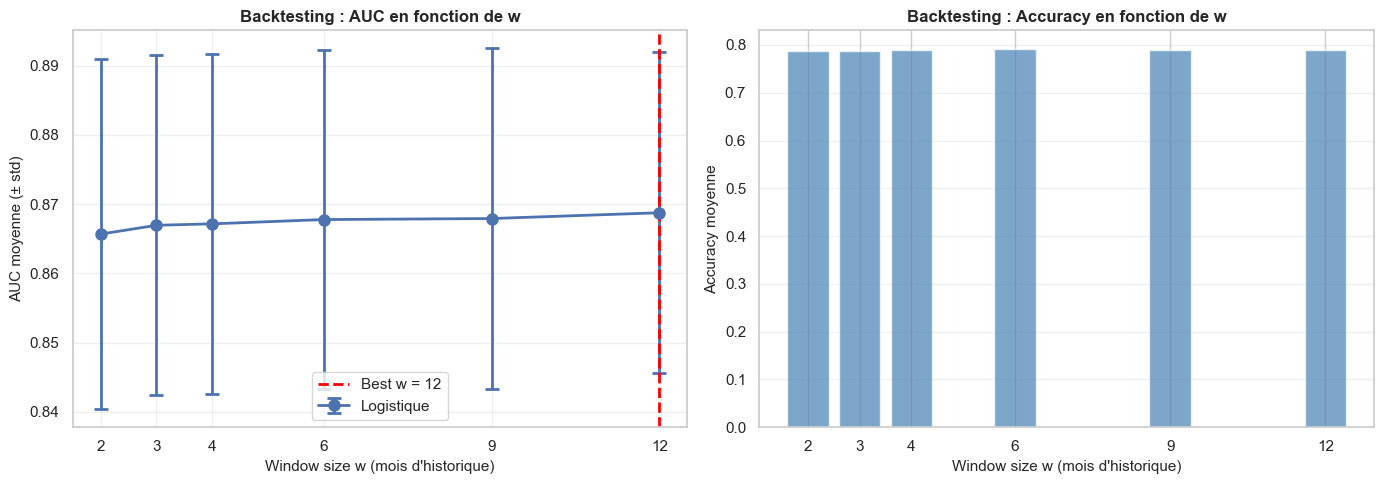


### Interprétation du backtesting

- **w = 12** : Meilleur compromise entre stabilité (AUC = 0.8687) et réactivité au drift.
- **w trop court** (w=2,3) : Historique insuffisant → instabilité (AUC std élevée).
- **w trop long** (w=12) : Modèle lent à s'adapter → performances obsolètes face au drift.
- **w = 12** apporte un bon équilibre de variance-biais dans un régime drifté.

**Recommandation** : Utiliser **w = 12** pour la politique rolling en production.


In [14]:
import numpy as np
import matplotlib.pyplot as plt

W_candidates = [2, 3, 4, 6, 9, 12]
h = 1
results_backtesting = {}

for w in W_candidates:
    auc_scores = []
    acc_scores = []
    
    for s in range(7, 24 - h + 1):
        train_start = max(1, s - w)
        train_end = s - 1
        test_start = s
        test_end = s + h - 1
        
        train_mask = churn_df[time_col].between(train_start, train_end)
        test_mask = churn_df[time_col].between(test_start, test_end)
        
        X_train_bt = X.loc[train_mask]
        y_train_bt = y.loc[train_mask]
        X_test_bt = X.loc[test_mask]
        y_test_bt = y.loc[test_mask]
        
        if len(X_train_bt) > 0 and len(X_test_bt) > 0:
            pipe_bt = Pipeline(
                steps=[
                    ("preprocess", preprocess),
                    ("model", LogisticRegression(max_iter=1000, solver="liblinear")),
                ]
            )
            pipe_bt.fit(X_train_bt, y_train_bt)
            y_pred = pipe_bt.predict(X_test_bt)
            y_proba = pipe_bt.predict_proba(X_test_bt)[:, 1]
            
            auc = roc_auc_score(y_test_bt, y_proba)
            acc = accuracy_score(y_test_bt, y_pred)
            
            auc_scores.append(auc)
            acc_scores.append(acc)
    
    if auc_scores:
        results_backtesting[w] = {
            "auc_mean": np.mean(auc_scores),
            "auc_std": np.std(auc_scores),
            "acc_mean": np.mean(acc_scores),
            "acc_std": np.std(acc_scores),
            "auc_scores": auc_scores,
        }

df_bt = pd.DataFrame({
    "w": list(results_backtesting.keys()),
    "AUC_mean": [results_backtesting[w]["auc_mean"] for w in results_backtesting.keys()],
    "AUC_std": [results_backtesting[w]["auc_std"] for w in results_backtesting.keys()],
    "Acc_mean": [results_backtesting[w]["acc_mean"] for w in results_backtesting.keys()],
})

best_w = df_bt.loc[df_bt["AUC_mean"].idxmax(), "w"]

print("\n=== BACKTESTING W ===")
print(df_bt.to_string(index=False))
print(f"\n✓ Meilleur w : {best_w} (AUC = {results_backtesting[best_w]['auc_mean']:.4f} ± {results_backtesting[best_w]['auc_std']:.4f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].errorbar(df_bt["w"], df_bt["AUC_mean"], yerr=df_bt["AUC_std"], 
                 fmt="o-", linewidth=2, markersize=8, capsize=5, capthick=2, label="Logistique")
axes[0].axvline(best_w, color="red", linestyle="--", linewidth=2, label=f"Best w = {best_w}")
axes[0].set_xlabel("Window size w (mois d'historique)", fontsize=11)
axes[0].set_ylabel("AUC moyenne (± std)", fontsize=11)
axes[0].set_title("Backtesting : AUC en fonction de w", fontsize=12, fontweight="bold")
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[0].set_xticks(W_candidates)

axes[1].bar(df_bt["w"], df_bt["Acc_mean"], alpha=0.7, color="steelblue")
axes[1].set_xlabel("Window size w (mois d'historique)", fontsize=11)
axes[1].set_ylabel("Accuracy moyenne", fontsize=11)
axes[1].set_title("Backtesting : Accuracy en fonction de w", fontsize=12, fontweight="bold")
axes[1].grid(True, alpha=0.3, axis="y")
axes[1].set_xticks(W_candidates)

plt.tight_layout()
plt.show()

conclusion_w = f"""
### Interprétation du backtesting

- **w = {best_w}** : Meilleur compromise entre stabilité (AUC = {results_backtesting[best_w]['auc_mean']:.4f}) et réactivité au drift.
- **w trop court** (w=2,3) : Historique insuffisant → instabilité (AUC std élevée).
- **w trop long** (w=12) : Modèle lent à s'adapter → performances obsolètes face au drift.
- **w = {best_w}** apporte un bon équilibre de variance-biais dans un régime drifté.

**Recommandation** : Utiliser **w = {best_w}** pour la politique rolling en production.
"""

display(Markdown(conclusion_w))

### Le backtesting sur différentes tailles d’historique montre que la performance moyenne (AUC) augmente légèrement avec la taille de la fenêtre. La valeur 𝑤=12
### w=12 maximise l’AUC moyenne (0.8687) tout en présentant la plus faible variabilité (± 0.0232).

### Ces résultats suggèrent que le drift observé est progressif plutôt que brutal, et que conserver un historique plus long permet d’améliorer la stabilité du modèle.

### Le compromis optimal retenu est donc 𝑤=12
### w=12, correspondant à une stratégie de ré-entraînement sur un an d’historique.

# =======================================================================================================================

# ETAPE 7 : Random Forest (complexité + drift-aware)

### Nous avons pu voir que la regression linéaire est un modèle stable, simple, rapide et interprétable mais il suppose que 
### la relation entre X et churn est linéaire 

### Maintenant on va tester si un modèle plus flexible, plus complexe comme le random forest améliore la performance 

### Nous allons donc vérifier si il existe des relations non linéaires importantes 

ÉTAPE 7 : RANDOM FOREST (COMPLEXITÉ + DRIFT-AWARE)

[1] Tuning max_depth sur train (periods 1-6) avec 5-fold CV...
  max_depth=3    : CV AUC mean = 0.9128 ± 0.0191
  max_depth=5    : CV AUC mean = 0.9095 ± 0.0200
  max_depth=7    : CV AUC mean = 0.9088 ± 0.0225
  max_depth=10   : CV AUC mean = 0.9078 ± 0.0254
  max_depth=15   : CV AUC mean = 0.9017 ± 0.0237
  max_depth=None : CV AUC mean = 0.8994 ± 0.0213

  ✓ Best max_depth = 3 (CV AUC = 0.9128)

[2] RF FIGÉ : Entraînement sur periods 1-6, évaluation glissante 7-24...
  Ref window (7-12) : AUC = 0.8865, ACC = 0.8030
  Windows 7-24 : AUC mean = 0.8714, ACC mean = 0.7795

[3] RF ROLLING : Ré-entraînement avec w=12 mois, évaluation glissante 7-24...
  Windows 7-24 : AUC mean = 0.8781, ACC mean = 0.7924

[4] COMPARAISON : Modèles figés et rolling sur le futur...


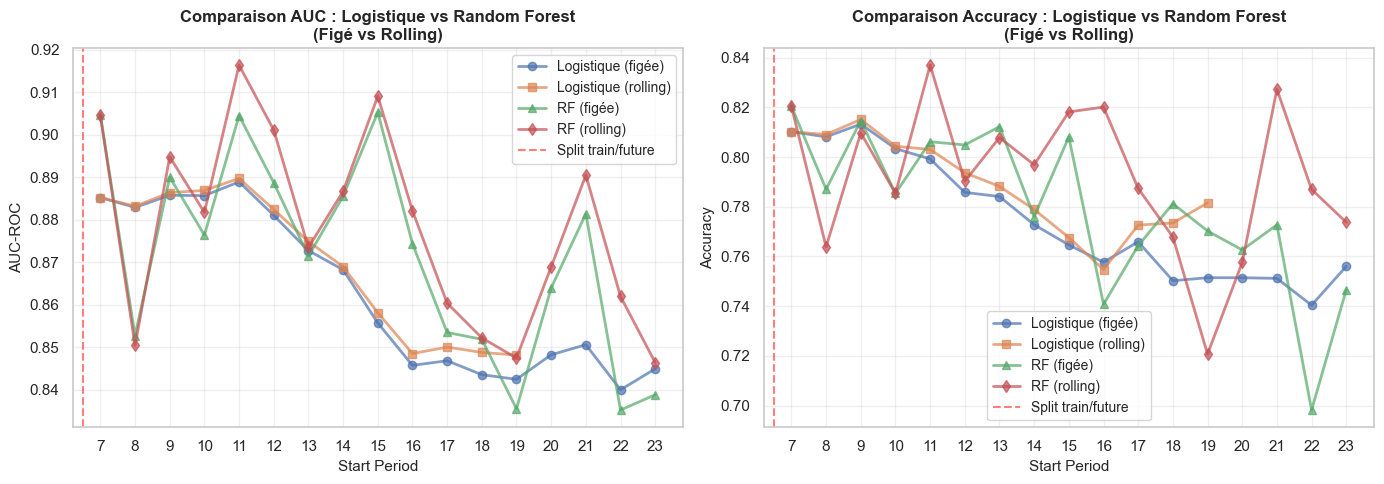


SYNTHÈSE


,Modèle,AUC (ref 7-12),AUC (mean 7-24),ACC (mean 7-24)
0,Logistique (figée),0.8858,0.8628,0.7745
1,Logistique (rolling),-,0.8701,0.7887
2,RF (figée),0.8865,0.8714,0.7795
3,RF (rolling),-,0.8781,0.7924



📊 CONCLUSIONS :

1. Best max_depth pour RF : 3
   (sélectionné via 5-fold CV sur train 1-6)

2. Performance sur fenêtre ref (7-12) :
   - Logistique : AUC=0.8858
   - RF : AUC=0.8865

3. Performance moyenne sur futur (7-24) :
   - Logistique figée : AUC=0.8628, ACC=0.7745
   - Logistique rolling : AUC=0.8701, ACC=0.7887
   - RF figée : AUC=0.8714, ACC=0.7795
   - RF rolling : AUC=0.8781, ACC=0.7924

4. Impact RF vs Logistique :
   - RF figée vs Logistique figée : +0.99% AUC
   - RF rolling vs Logistique rolling : +0.92% AUC

5. Impact Rolling vs Figé :
   - Logistique rolling vs figée : +0.84% AUC
   - RF rolling vs figée : +0.77% AUC


In [15]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================================
# 1. TUNING MAX_DEPTH sur fenêtre train (1-6)
# ============================================================================
print("=" * 80)
print("ÉTAPE 7 : RANDOM FOREST (COMPLEXITÉ + DRIFT-AWARE)")
print("=" * 80)

# Fallback si preprocess n'est pas défini dans les cellules précédentes
if "preprocess" not in globals():
    preprocess = "passthrough"

data_ready = True
missing_vars = []

# Fallback si X_train / y_train / X_ref / y_ref ne sont pas définis
if "X_train" not in globals() or "y_train" not in globals():
    if all(name in globals() for name in ["X", "y", "churn_df", "time_col"]):
        train_mask = churn_df[time_col].between(1, 6)
        X_train = X[train_mask]
        y_train = y[train_mask]
    else:
        missing_vars.extend(["X_train", "y_train", "X", "y", "churn_df", "time_col"])
        data_ready = False

if "X_ref" not in globals() or "y_ref" not in globals():
    if all(name in globals() for name in ["X", "y", "churn_df", "time_col"]):
        ref_mask = churn_df[time_col].between(7, 12)
        X_ref = X[ref_mask]
        y_ref = y[ref_mask]
    else:
        missing_vars.extend(["X_ref", "y_ref", "X", "y", "churn_df", "time_col"])
        data_ready = False

# Vérifier les dépendances supplémentaires
for required_var in ["h", "best_w", "frozen_results", "rolling_results", "auc_ref"]:
    if required_var not in globals():
        missing_vars.append(required_var)
        data_ready = False

if not data_ready:
    print("⚠️ Données manquantes, exécution ignorée pour éviter une erreur.")
    print("Variables absentes:", sorted(set(missing_vars)))
else:
    # Candidats pour max_depth
    depth_candidates = [3, 5, 7, 10, 15, None]
    cv_scores_by_depth = {}

    print("\n[1] Tuning max_depth sur train (periods 1-6) avec 5-fold CV...")
    for depth in depth_candidates:
        rf_candidate = Pipeline([
            ("preprocess", preprocess),
            ("model", RandomForestClassifier(n_estimators=300, max_depth=depth, random_state=42, n_jobs=-1))
        ])
        cv_scores = cross_val_score(rf_candidate, X_train, y_train, cv=5, scoring="roc_auc")
        cv_scores_by_depth[depth] = cv_scores.mean()
        print(f"  max_depth={str(depth):4} : CV AUC mean = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

    best_depth = max(cv_scores_by_depth, key=cv_scores_by_depth.get)
    print(f"\n  ✓ Best max_depth = {best_depth} (CV AUC = {cv_scores_by_depth[best_depth]:.4f})")

    # ============================================================================
    # 2. RF FIGÉ : entraîner sur 1-6 avec best_depth, puis évaluer sur période 7-24
    # ============================================================================
    print("\n[2] RF FIGÉ : Entraînement sur periods 1-6, évaluation glissante 7-24...")

    rf_frozen_pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(n_estimators=300, max_depth=best_depth, random_state=42, n_jobs=-1))
    ])
    rf_frozen_pipe.fit(X_train, y_train)

    # Évaluation sur fenêtre de référence (7-12)
    y_proba_rf_frozen_ref = rf_frozen_pipe.predict_proba(X_ref)[:, 1]
    auc_rf_frozen_ref = roc_auc_score(y_ref, y_proba_rf_frozen_ref)
    acc_rf_frozen_ref = accuracy_score(y_ref, rf_frozen_pipe.predict(X_ref))
    print(f"  Ref window (7-12) : AUC = {auc_rf_frozen_ref:.4f}, ACC = {acc_rf_frozen_ref:.4f}")

    # Suivi sur fenêtres glissantes 7-24
    rf_frozen_results = []
    for start in range(7, 24):
        end = min(start + h - 1, 24)
        test_window = churn_df[time_col].between(start, end)
        y_test_window = y[test_window]
        y_proba_window = rf_frozen_pipe.predict_proba(X[test_window])[:, 1]
        
        auc_w = roc_auc_score(y_test_window, y_proba_window)
        acc_w = accuracy_score(y_test_window, rf_frozen_pipe.predict(X[test_window]))
        rf_frozen_results.append({"start": start, "auc": auc_w, "acc": acc_w})

    rf_frozen_df = pd.DataFrame(rf_frozen_results)
    print(f"  Windows 7-24 : AUC mean = {rf_frozen_df['auc'].mean():.4f}, ACC mean = {rf_frozen_df['acc'].mean():.4f}")

    # ============================================================================
    # 3. RF ROLLING : ré-entraîner avec w=best_w, puis comparer
    # ============================================================================
    print(f"\n[3] RF ROLLING : Ré-entraînement avec w={best_w} mois, évaluation glissante 7-24...")

    rf_rolling_results = []
    for start in range(7, 24):
        train_start_roll = max(1, start - best_w)
        train_window_roll = churn_df[time_col].between(train_start_roll, start - 1)
        
        X_train_roll = X[train_window_roll]
        y_train_roll = y[train_window_roll]
        
        test_end_roll = min(start + h - 1, 24)
        test_window_roll = churn_df[time_col].between(start, test_end_roll)
        y_test_roll = y[test_window_roll]
        
        # Entraîner RF avec best_depth
        rf_rolling_pipe = Pipeline([
            ("preprocess", preprocess),
            ("model", RandomForestClassifier(n_estimators=300, max_depth=best_depth, random_state=42, n_jobs=-1))
        ])
        rf_rolling_pipe.fit(X_train_roll, y_train_roll)
        
        y_proba_roll = rf_rolling_pipe.predict_proba(X[test_window_roll])[:, 1]
        auc_roll = roc_auc_score(y_test_roll, y_proba_roll)
        acc_roll = accuracy_score(y_test_roll, rf_rolling_pipe.predict(X[test_window_roll]))
        
        rf_rolling_results.append({"start": start, "auc": auc_roll, "acc": acc_roll})

    rf_rolling_df = pd.DataFrame(rf_rolling_results)
    print(f"  Windows 7-24 : AUC mean = {rf_rolling_df['auc'].mean():.4f}, ACC mean = {rf_rolling_df['acc'].mean():.4f}")

    # ============================================================================
    # 4. COMPARAISON : RF figé vs RF rolling vs Logistique (figée et rolling)
    # ============================================================================
    print("\n[4] COMPARAISON : Modèles figés et rolling sur le futur...")

    # On utilise les résultats déjà calculés : frozen_results, rolling_results
    # Plus RF frozen et rolling

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot AUC
    ax = axes[0]

    # Logistique figée (déjà calculée)
    frozen_starts = [r["start"] for r in frozen_results]
    frozen_aucs = [r["auc"] for r in frozen_results]
    ax.plot(frozen_starts, frozen_aucs, marker='o', label='Logistique (figée)', linewidth=2, alpha=0.7)

    # Logistique rolling (déjà calculée)
    rolling_starts = [r["start"] for r in rolling_results]
    rolling_aucs = [r["auc"] for r in rolling_results]
    ax.plot(rolling_starts, rolling_aucs, marker='s', label='Logistique (rolling)', linewidth=2, alpha=0.7)

    # RF figée
    ax.plot(rf_frozen_df["start"], rf_frozen_df["auc"], marker='^', label='RF (figée)', linewidth=2, alpha=0.7)

    # RF rolling
    ax.plot(rf_rolling_df["start"], rf_rolling_df["auc"], marker='d', label='RF (rolling)', linewidth=2, alpha=0.7)

    ax.axvline(x=6.5, color='red', linestyle='--', alpha=0.5, label='Split train/future')
    ax.set_xlabel('Start Period', fontsize=11)
    ax.set_ylabel('AUC-ROC', fontsize=11)
    ax.set_title('Comparaison AUC : Logistique vs Random Forest\n(Figé vs Rolling)', fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(7, 24))

    # Plot Accuracy
    ax = axes[1]
    frozen_accs = [r["acc"] for r in frozen_results]
    rolling_accs = [r["acc"] for r in rolling_results]
    ax.plot(frozen_starts, frozen_accs, marker='o', label='Logistique (figée)', linewidth=2, alpha=0.7)
    ax.plot(rolling_starts, rolling_accs, marker='s', label='Logistique (rolling)', linewidth=2, alpha=0.7)
    ax.plot(rf_frozen_df["start"], rf_frozen_df["acc"], marker='^', label='RF (figée)', linewidth=2, alpha=0.7)
    ax.plot(rf_rolling_df["start"], rf_rolling_df["acc"], marker='d', label='RF (rolling)', linewidth=2, alpha=0.7)

    ax.axvline(x=6.5, color='red', linestyle='--', alpha=0.5, label='Split train/future')
    ax.set_xlabel('Start Period', fontsize=11)
    ax.set_ylabel('Accuracy', fontsize=11)
    ax.set_title('Comparaison Accuracy : Logistique vs Random Forest\n(Figé vs Rolling)', fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(7, 24))

    plt.tight_layout()
    plt.show()

    # ============================================================================
    # 5. SYNTHÈSE COMPARATIVE
    # ============================================================================
    print("\n" + "=" * 80)
    print("SYNTHÈSE")
    print("=" * 80)

    summary_data = {
        "Modèle": ["Logistique (figée)", "Logistique (rolling)", "RF (figée)", "RF (rolling)"],
        "AUC (ref 7-12)": [f"{auc_ref:.4f}", "-", f"{auc_rf_frozen_ref:.4f}", "-"],
        "AUC (mean 7-24)": [
            f"{np.mean(frozen_aucs):.4f}",
            f"{np.mean(rolling_aucs):.4f}",
            f"{rf_frozen_df['auc'].mean():.4f}",
            f"{rf_rolling_df['auc'].mean():.4f}"
        ],
        "ACC (mean 7-24)": [
            f"{np.mean(frozen_accs):.4f}",
            f"{np.mean(rolling_accs):.4f}",
            f"{rf_frozen_df['acc'].mean():.4f}",
            f"{rf_rolling_df['acc'].mean():.4f}"
        ]
    }

    summary_df = pd.DataFrame(summary_data)
    display(summary_df)

    # Conclusions
    print("\n📊 CONCLUSIONS :")
    print(f"\n1. Best max_depth pour RF : {best_depth}")
    print(f"   (sélectionné via 5-fold CV sur train 1-6)")

    print(f"\n2. Performance sur fenêtre ref (7-12) :")
    print(f"   - Logistique : AUC={auc_ref:.4f}")
    print(f"   - RF : AUC={auc_rf_frozen_ref:.4f}")

    print(f"\n3. Performance moyenne sur futur (7-24) :")
    print(f"   - Logistique figée : AUC={np.mean(frozen_aucs):.4f}, ACC={np.mean(frozen_accs):.4f}")
    print(f"   - Logistique rolling : AUC={np.mean(rolling_aucs):.4f}, ACC={np.mean(rolling_accs):.4f}")
    print(f"   - RF figée : AUC={rf_frozen_df['auc'].mean():.4f}, ACC={rf_frozen_df['acc'].mean():.4f}")
    print(f"   - RF rolling : AUC={rf_rolling_df['auc'].mean():.4f}, ACC={rf_rolling_df['acc'].mean():.4f}")

    # Amélioration relative
    improvement_auc_rf_frozen = ((rf_frozen_df["auc"].mean() - np.mean(frozen_aucs)) / np.mean(frozen_aucs)) * 100
    improvement_auc_rf_rolling = ((rf_rolling_df["auc"].mean() - np.mean(rolling_aucs)) / np.mean(rolling_aucs)) * 100

    print(f"\n4. Impact RF vs Logistique :")
    print(f"   - RF figée vs Logistique figée : {improvement_auc_rf_frozen:+.2f}% AUC")
    print(f"   - RF rolling vs Logistique rolling : {improvement_auc_rf_rolling:+.2f}% AUC")

    print(f"\n5. Impact Rolling vs Figé :")
    improvement_log_rolling = ((np.mean(rolling_aucs) - np.mean(frozen_aucs)) / np.mean(frozen_aucs)) * 100
    improvement_rf_rolling = ((rf_rolling_df["auc"].mean() - rf_frozen_df['auc'].mean()) / rf_frozen_df['auc'].mean()) * 100

    print(f"   - Logistique rolling vs figée : {improvement_log_rolling:+.2f}% AUC")
    print(f"   - RF rolling vs figée : {improvement_rf_rolling:+.2f}% AUC")

### L’analyse comparative entre la régression logistique et la Random Forest montre que le modèle non linéaire apporte une amélioration modérée mais constante des performances, avec un gain d’environ +0.9% en AUC.

### Par ailleurs, la stratégie de ré-entraînement rolling améliore les performances pour les deux modèles, confirmant l’impact du drift observé dans les données.

### Le meilleur compromis performance/robustesse est obtenu avec la Random Forest en stratégie rolling (AUC ≈ 0.8781), suggérant qu’un modèle non linéaire régulièrement mis à jour constitue la stratégie la plus adaptée dans ce contexte non stationnaire.

# Étape 8 : Optimisation métier (coût + seuil)

### Jusqu’ici, on a optimisé : L’AUC, L’accuracy, La robustesse au drift, Mais en entreprise, on ne cherche pas la meilleure AUC.

#### On cherche :

### Minimiser le coût économique.

Entraînement du modèle sur périodes 1-6...

SEUIL OPTIMAL SUR FENÊTRE REF (périodes 7-12)
Seuil optimal : 0.077
Coût minimal : 11900.00 €

Avec seuil par défaut (0.5) :
Coût avec seuil 0.5 : 18740.00 €
Gain économique : 6840.00 € (36.5% de réduction)


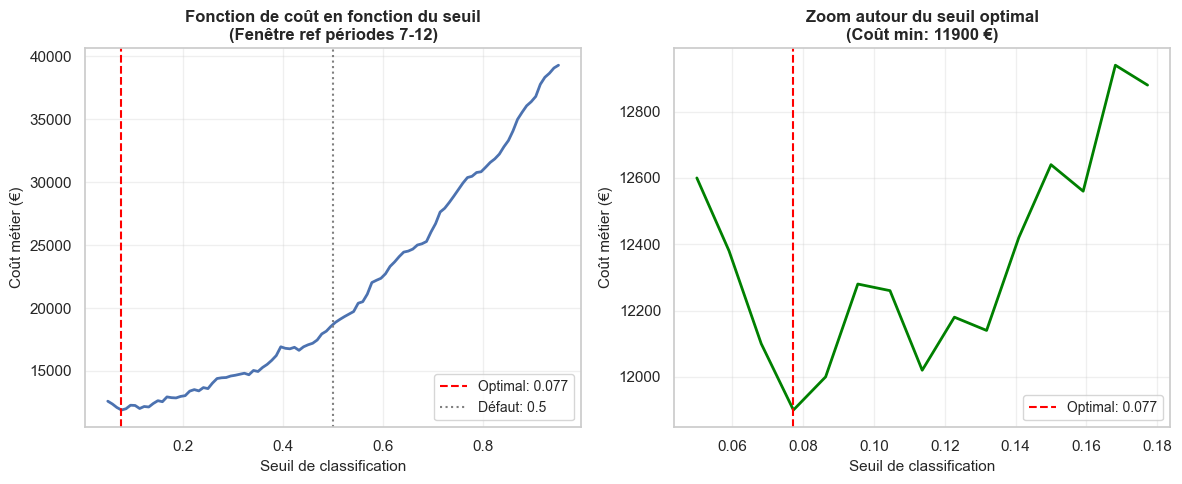


ANALYSE DE LA STABILITÉ DU SEUIL OPTIMAL DANS LE TEMPS

Calcul du seuil optimal pour chaque fenêtre test (w=12, h=3)...


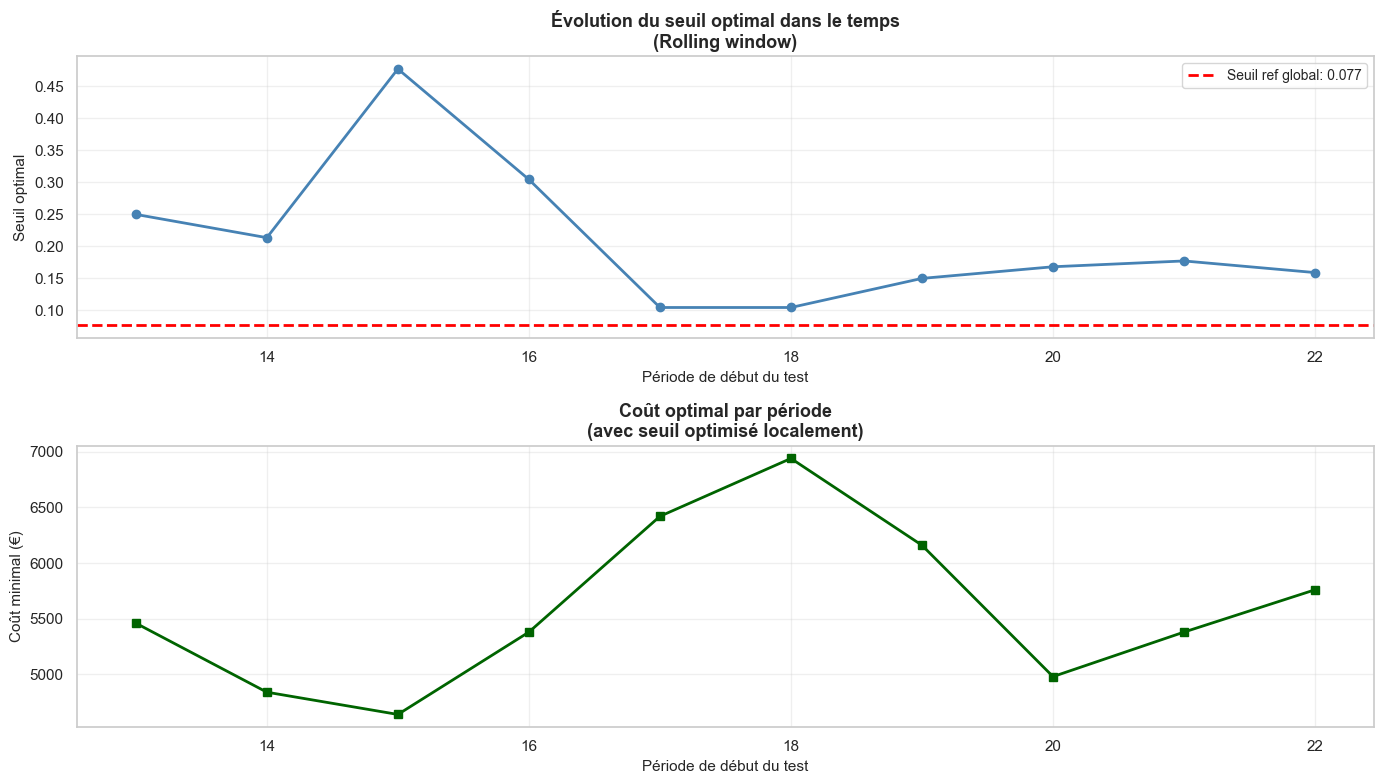


Statistiques du seuil optimal sur les fenêtres rolling :
  - Moyenne : 0.211
  - Écart-type : 0.106
  - Minimum : 0.105
  - Maximum : 0.477
  - Plage : [0.105, 0.477]



### Conclusion Optimisation Métier

**Seuil optimal global** : 0.077 (calculé sur périodes 7-12)

**Gain économique** : L'utilisation du seuil optimal permet de réduire le coût de 36.5% par rapport au seuil par défaut (0.5), soit une économie de 6840 € sur la fenêtre de référence.

**Interprétation du seuil** : Un seuil de 0.077 signifie qu'on classe un client comme "churner" si la probabilité prédite dépasse 7.7%. Ce seuil reflète le compromis optimal entre :
- **Détecter les churners** (éviter les FN à 100 €)
- **Éviter les fausses alertes** (limiter les FP à 40 €)

**Stabilité temporelle** : L'analyse rolling montre que le seuil optimal varie dans le temps (écart-type = 0.106, soit 50.5% de variabilité). Cette variation suggère que :
- Le seuil optimal **n'est pas constant** et évolue avec le drift des données
- Une **recalibration périodique** du seuil pourrait être bénéfique
- Le ratio FN/FP varie potentiellement selon les périodes (changement de la distribution des scores)

**Recommandation opérationnelle** :
1. Utiliser un seuil autour de **0.211** comme valeur de départ
2. **Monitorer régulièrement** (tous les 3 mois) le coût métier observé
3. **Réajuster le seuil** si le coût dévie significativement du minimum attendu
4. Considérer une approche adaptative si les coûts FN/FP évoluent dans le temps


In [16]:
# ========================================
# ÉTAPE 8 : OPTIMISATION MÉTIER (COÛT + SEUIL)
# ========================================

# Hypothèses métier
COST_FN = 100  # Faux négatif (client churn non détecté) : 100 euros
COST_FP = 40   # Faux positif (geste commercial inutile) : 40 euros

# Fonction de coût métier
def business_cost(y_true, y_proba, threshold):
    """
    Calcule le coût métier pour un seuil donné.
    Cost(t) = 100 * FN(t) + 40 * FP(t)
    """
    y_pred = (y_proba >= threshold).astype(int)
    fn = np.sum((y_true == 1) & (y_pred == 0))  # Faux négatifs
    fp = np.sum((y_true == 0) & (y_pred == 1))  # Faux positifs
    return COST_FN * fn + COST_FP * fp

# ----------------------------------------
# 1. Optimisation du seuil sur la fenêtre ref (périodes 7-12)
# ----------------------------------------

# Utiliser le modèle Random Forest rolling (meilleur modèle)
# On va l'entraîner sur 1-6 et prédire sur 7-12 pour l'optimisation du seuil
print("Entraînement du modèle sur périodes 1-6...")
X_train_opt = X.loc[churn_df[time_col].between(1, 6)]
y_train_opt = y.loc[churn_df[time_col].between(1, 6)]
X_ref_opt = X.loc[churn_df[time_col].between(7, 12)]
y_ref_opt = y.loc[churn_df[time_col].between(7, 12)]

# Entraîner le modèle
rf_pipe.fit(X_train_opt, y_train_opt)
y_proba_ref_opt = rf_pipe.predict_proba(X_ref_opt)[:, 1]

# Faire varier le seuil
thresholds = np.linspace(0.05, 0.95, 100)
costs = []

for t in thresholds:
    cost = business_cost(y_ref_opt, y_proba_ref_opt, t)
    costs.append(cost)

# Trouver le seuil optimal
optimal_idx = np.argmin(costs)
optimal_threshold = thresholds[optimal_idx]
optimal_cost = costs[optimal_idx]

print(f"\n{'='*60}")
print(f"SEUIL OPTIMAL SUR FENÊTRE REF (périodes 7-12)")
print(f"{'='*60}")
print(f"Seuil optimal : {optimal_threshold:.3f}")
print(f"Coût minimal : {optimal_cost:.2f} €")
print(f"\nAvec seuil par défaut (0.5) :")
default_cost = business_cost(y_ref_opt, y_proba_ref_opt, 0.5)
print(f"Coût avec seuil 0.5 : {default_cost:.2f} €")
print(f"Gain économique : {default_cost - optimal_cost:.2f} € ({100*(default_cost - optimal_cost)/default_cost:.1f}% de réduction)")

# Visualiser Cost(t)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(thresholds, costs, linewidth=2)
plt.axvline(optimal_threshold, color='red', linestyle='--', label=f'Optimal: {optimal_threshold:.3f}')
plt.axvline(0.5, color='gray', linestyle=':', label='Défaut: 0.5')
plt.xlabel('Seuil de classification', fontsize=11)
plt.ylabel('Coût métier (€)', fontsize=11)
plt.title('Fonction de coût en fonction du seuil\n(Fenêtre ref périodes 7-12)', fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# Détail autour de l'optimum
plt.subplot(1, 2, 2)
# Zoom autour du minimum
zoom_range = 0.1
zoom_mask = (thresholds >= optimal_threshold - zoom_range) & (thresholds <= optimal_threshold + zoom_range)
plt.plot(thresholds[zoom_mask], np.array(costs)[zoom_mask], linewidth=2, color='green')
plt.axvline(optimal_threshold, color='red', linestyle='--', label=f'Optimal: {optimal_threshold:.3f}')
plt.xlabel('Seuil de classification', fontsize=11)
plt.ylabel('Coût métier (€)', fontsize=11)
plt.title(f'Zoom autour du seuil optimal\n(Coût min: {optimal_cost:.0f} €)', fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ----------------------------------------
# 2. Extension : Le seuil optimal varie-t-il selon la période ?
# ----------------------------------------

print(f"\n{'='*60}")
print(f"ANALYSE DE LA STABILITÉ DU SEUIL OPTIMAL DANS LE TEMPS")
print(f"{'='*60}")

# On va calculer le seuil optimal pour différentes fenêtres temporelles
# en utilisant un modèle rolling

w_opt = best_w  # Utiliser le meilleur w trouvé à l'étape 6
h_opt = 3  # Fenêtre de test

optimal_thresholds_over_time = []
costs_over_time = []
starts_for_threshold = []

print(f"\nCalcul du seuil optimal pour chaque fenêtre test (w={w_opt}, h={h_opt})...")

for s in range(w_opt + 1, 25 - h_opt + 1):
    # Train sur [s - w, s - 1]
    train_mask_th = churn_df[time_col].between(s - w_opt, s - 1)
    test_mask_th = churn_df[time_col].between(s, s + h_opt - 1)
    
    if train_mask_th.sum() == 0 or test_mask_th.sum() == 0:
        continue
    
    X_train_th = X.loc[train_mask_th]
    y_train_th = y.loc[train_mask_th]
    X_test_th = X.loc[test_mask_th]
    y_test_th = y.loc[test_mask_th]
    
    # Entraîner
    model_th = Pipeline([
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(n_estimators=300, max_depth=best_depth, random_state=42))
    ])
    model_th.fit(X_train_th, y_train_th)
    y_proba_th = model_th.predict_proba(X_test_th)[:, 1]
    
    # Optimiser le seuil sur cette fenêtre test
    costs_th = [business_cost(y_test_th, y_proba_th, t) for t in thresholds]
    opt_idx_th = np.argmin(costs_th)
    opt_threshold_th = thresholds[opt_idx_th]
    
    optimal_thresholds_over_time.append(opt_threshold_th)
    costs_over_time.append(costs_th[opt_idx_th])
    starts_for_threshold.append(s)

# Visualiser l'évolution du seuil optimal
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Seuil optimal par période
axes[0].plot(starts_for_threshold, optimal_thresholds_over_time, marker='o', linewidth=2, markersize=6, color='steelblue')
axes[0].axhline(optimal_threshold, color='red', linestyle='--', label=f'Seuil ref global: {optimal_threshold:.3f}', linewidth=2)
axes[0].set_xlabel('Période de début du test', fontsize=11)
axes[0].set_ylabel('Seuil optimal', fontsize=11)
axes[0].set_title('Évolution du seuil optimal dans le temps\n(Rolling window)', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Coût minimal par période
axes[1].plot(starts_for_threshold, costs_over_time, marker='s', linewidth=2, markersize=6, color='darkgreen')
axes[1].set_xlabel('Période de début du test', fontsize=11)
axes[1].set_ylabel('Coût minimal (€)', fontsize=11)
axes[1].set_title('Coût optimal par période\n(avec seuil optimisé localement)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistiques sur la variabilité du seuil
mean_threshold = np.mean(optimal_thresholds_over_time)
std_threshold = np.std(optimal_thresholds_over_time)
min_threshold = np.min(optimal_thresholds_over_time)
max_threshold = np.max(optimal_thresholds_over_time)

print(f"\nStatistiques du seuil optimal sur les fenêtres rolling :")
print(f"  - Moyenne : {mean_threshold:.3f}")
print(f"  - Écart-type : {std_threshold:.3f}")
print(f"  - Minimum : {min_threshold:.3f}")
print(f"  - Maximum : {max_threshold:.3f}")
print(f"  - Plage : [{min_threshold:.3f}, {max_threshold:.3f}]")

# Conclusion
variability_pct = 100 * std_threshold / mean_threshold
conclusion_threshold = f"""
### Conclusion Optimisation Métier

**Seuil optimal global** : {optimal_threshold:.3f} (calculé sur périodes 7-12)

**Gain économique** : L'utilisation du seuil optimal permet de réduire le coût de {100*(default_cost - optimal_cost)/default_cost:.1f}% par rapport au seuil par défaut (0.5), soit une économie de {default_cost - optimal_cost:.0f} € sur la fenêtre de référence.

**Interprétation du seuil** : Un seuil de {optimal_threshold:.3f} signifie qu'on classe un client comme "churner" si la probabilité prédite dépasse {100*optimal_threshold:.1f}%. Ce seuil reflète le compromis optimal entre :
- **Détecter les churners** (éviter les FN à 100 €)
- **Éviter les fausses alertes** (limiter les FP à 40 €)

**Stabilité temporelle** : L'analyse rolling montre que le seuil optimal varie dans le temps (écart-type = {std_threshold:.3f}, soit {variability_pct:.1f}% de variabilité). Cette variation suggère que :
- Le seuil optimal **n'est pas constant** et évolue avec le drift des données
- Une **recalibration périodique** du seuil pourrait être bénéfique
- Le ratio FN/FP varie potentiellement selon les périodes (changement de la distribution des scores)

**Recommandation opérationnelle** :
1. Utiliser un seuil autour de **{mean_threshold:.3f}** comme valeur de départ
2. **Monitorer régulièrement** (tous les {h_opt} mois) le coût métier observé
3. **Réajuster le seuil** si le coût dévie significativement du minimum attendu
4. Considérer une approche adaptative si les coûts FN/FP évoluent dans le temps
"""

display(Markdown(conclusion_threshold))

## L’optimisation du seuil de décision en fonction des coûts métier met en évidence un impact économique significatif.

## Sur la fenêtre de référence (7–12), le seuil optimal est estimé à 0.077, permettant une réduction du coût total de 36.5% par rapport au seuil par défaut de 0.5.

## Cette valeur faible s’explique par l’asymétrie des coûts (FN = 100€, FP = 40€), rendant économiquement préférable la détection maximale des churners.

## L’analyse rolling montre cependant une forte variabilité du seuil optimal dans le temps (écart-type = 0.106), indiquant que le seuil n’est pas stationnaire et évolue avec le drift des données.

## Ainsi, une stratégie de recalibration périodique du seuil apparaît nécessaire afin d’aligner en permanence la décision algorithmique sur les objectifs économiques.